# **Modelling**

## Objectives

* Build and evaluate baseline classification models that predict hazardous status using geometric and orbital features (diameter, miss_distance, relative_velocity, absolute_magnitude, observations).

## Inputs

* `features_model.csv` 

## Outputs

* Trained baseline models: Logistic Regression (with regularization), Random Forest, XGBoost (optional).
* Evaluation artifacts: cross-validated metrics (ROC-AUC, PR-AUC), confusion matrices, calibration plots, feature importance (coefficients/SHAP).
* Results table comparing models.


## Success Criteria

* Reproducible pipeline: running the notebook top-to-bottom recreates models and metrics.
* At least one model achieves ROC-AUC > 0.70 (adjust threshold if class imbalance makes this infeasible); or shows improvement over a baseline (random or constant classifier).
* Models are interpretable: logistic regression coefficients make sense (direction), and feature importances/SHAP align with EDA findings.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\mikee\\Desktop\\Near-Earth-Asteroid-Analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\mikee\\Desktop\\Near-Earth-Asteroid-Analysis'

# ML - Tree Models

Import Libraries

In [4]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### Objective
* Predict if an asteroid is hazardoud based on physical/ orbital properties.
* Target variable `hazardous_enc`

#### Workflow
* Load Data
* Select Features for training
* Split Train and Test Data
* Create Pipeline - Encode categorical data (label encoding)
* Train Tree Based Models
* Check feature importance 
* Analyse/ retest parameters etc


1. Load Data

In [5]:
#load feature_models.csv
df_model = pd.read_csv('Data/Processed/features_model.csv')
df_model.head(4).T

,0,1,2,3
name,(1983 LC),(1986 NA),(1988 NE),(1989 AZ)
est_diameter_min,0.342417,0.28481,0.402305,0.319562
est_diameter_max,0.765667,0.636854,0.89958,0.714562
relative_velocity_mean,60192.646491,51810.077045,22815.738845,55184.046572
miss_distance_mean,18476643.271,70052459.208572,65063306.320902,25604655.93738
miss_distance_min,10334476.5074,70052459.208572,65063306.320902,20219801.806052
absolute_magnitude_mean,19.45,19.85,19.1,19.6
hazardous,True,False,False,False
observations,2,1,1,2
est_diameter_range,0.42325,0.352044,0.497276,0.395


In [6]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
est_diameter_min,10155.0,3.216389e-01,5.700167e-01,0.086807,1.332156e-01,2.111324e-01,3.544509e-01,3.789265e+01
est_diameter_max,10155.0,7.192066e-01,1.274596e+00,0.194106,2.978791e-01,4.721065e-01,7.925764e-01,8.473054e+01
relative_velocity_mean,10155.0,5.687184e+04,2.765598e+04,646.320239,3.743231e+04,5.503513e+04,7.367590e+04,2.282422e+05
miss_distance_mean,10155.0,4.285755e+07,1.483938e+07,832144.928659,3.388199e+07,4.407155e+07,5.305426e+07,7.479865e+07
miss_distance_min,10155.0,3.201981e+07,1.776006e+07,143272.707499,1.757402e+07,3.029674e+07,4.454890e+07,7.479865e+07
absolute_magnitude_mean,10155.0,2.027937e+01,1.526651e+00,9.230000,1.937500e+01,2.050000e+01,2.150000e+01,2.243000e+01
observations,10155.0,3.260266e+00,3.135806e+00,1.000000,1.000000e+00,2.000000e+00,4.000000e+00,4.300000e+01
est_diameter_range,10155.0,3.975676e-01,7.045794e-01,0.107299,1.646635e-01,2.609741e-01,4.381255e-01,4.683789e+01
est_diameter_mean,10155.0,5.204227e-01,9.223064e-01,0.140457,2.155473e-01,3.416195e-01,5.735137e-01,6.131160e+01
est_diameter_min_log1p,10155.0,2.519293e-01,1.988458e-01,0.083244,1.250592e-01,1.915558e-01,3.033960e-01,3.660805e+00


In [7]:
df_model.shape

(10155, 24)

### Select Features

For our tree based model we will select only categorical features (to be encoded) and raw data features.
`log1p` based features, `name` and `hazardous` (as we also have `hazadardous_enc`) will be dropped.

List of features to be included:
* feature_cols = [
    `est_diameter_mean`, `miss_distance_mean`, `relative_velocity_mean`,
    `absolute_magnitude_mean`, `observations`,
    `diameter_class`, `proximity_class`, `velocity_class`, `brightness_class`, `observation_class`
]
* target_col = `hazardous_enc`

Justification:
Loog values are not needed for tree models. Keeping catergorical and continuous feature will lead to some duplication of data, but should be pruned by feature importance test.

### Encoding Data

* Features to be encoded
    * `diameter_class`
    * `proximity_class`
    * `velocity_class`
    * `brightness_class`
    * `observation_class`

In [17]:
# Define features and target
feature_cols = [
    "est_diameter_mean", "miss_distance_mean", "relative_velocity_mean",
    "absolute_magnitude_mean", "observations",
    "diameter_class", "proximity_class", "velocity_class", "brightness_class", "observation_class"
]
df_tree_model = df_model[feature_cols + ['hazardous_enc']].copy()
df_tree_model.head(3).T

,0,1,2
est_diameter_mean,0.554042,0.460832,0.650942
miss_distance_mean,18476643.271,70052459.208572,65063306.320902
relative_velocity_mean,60192.646491,51810.077045,22815.738845
absolute_magnitude_mean,19.45,19.85,19.1
observations,2,1,1
diameter_class,medium,small,medium
proximity_class,medium,very_distant,very_distant
velocity_class,moderate,slow,slow
brightness_class,dim,dim,dim
observation_class,few,single,single


Create Train & Test Sets

In [18]:
#split the dataset into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_tree_model[feature_cols], df_tree_model['hazardous_enc'], test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8124, 10), (2031, 10), (8124,), (2031,))

In [ ]:
#Check target class distribution in train and test sets
print("Class balance (train):", y_train.value_counts(normalize=True).to_dict())
print("Class balance (test):", y_test.value_counts(normalize=True).to_dict())

Class balance (train): {0: 0.7865583456425406, 1: 0.21344165435745938}
Class balance (test): {0: 0.7838503200393895, 1: 0.21614967996061055}


Our Train and test groups have a good balance for our target class.

Next step is to create our pipeline - we will test several Tree Models simultaneously to see which perform best.

I am using RandomForest as my initial model - depending on results I will test other Tree Models to see which performs best

In [ ]:
from sklearn.pipeline import Pipeline
from feature_engine.imputation import MeanMedianImputer, CategoricalImputer
from feature_engine.encoding import OrdinalEncoder
from sklearn.feature_selection import SelectFromModel

# Define feature groups so the pipeline knows what to touch
NUMERIC_VARS = [
    "est_diameter_mean", "miss_distance_mean", "relative_velocity_mean",
    "absolute_magnitude_mean", "observations"
]
ORDINAL_VARS = [
    "diameter_class", "proximity_class", "velocity_class",
    "brightness_class", "observation_class"
]
# Create a function that builds a pipeline with a given model
# No scaling needed for tree-based models
def PipelineOptimization(model):
    pipeline_base = Pipeline(steps=[
        # 1) Impute numeric (median is robust to skew)
        ("num_imputer", MeanMedianImputer(imputation_method="median", variables=NUMERIC_VARS)),

        # 2) Impute categoricals (mode/most frequent)
        ("cat_imputer", CategoricalImputer(imputation_method="frequent", variables=ORDINAL_VARS)),

        # 3) Ordinal-encode ordered categories (keeps rank meaning for trees)
        ("ord_encoder", OrdinalEncoder(encoding_method="arbitrary", variables=ORDINAL_VARS)),

        # 4) Feature selection from model (uses model’s importances)
        ("feat_selection", SelectFromModel(model)),

        # 5) Final estimator
        ("model", model),
    ])
    return pipeline_base


Our next step is to define our candidate tree models to testing

In [23]:
# Define candidate models to test first import the models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
#define the candidates
candidates = {
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
}

Next we create a testing loop for our models

In [ ]:
# --- Train & evaluate loop ---
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, classification_report
# Create empty lists to store results
results = []
reports = {}
# Loop through candidates
for name, model in candidates.items():
    pipe = PipelineOptimization(model)
    pipe.fit(X_train, y_train)

    # Predict on test set
    y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None
    y_pred = pipe.predict(X_test)

    # Evaluate metrics
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    pr  = average_precision_score(y_test, y_prob) if y_prob is not None else np.nan

    # Store results
    results.append({"model": name, "accuracy": acc, "roc_auc": roc, "pr_auc": pr})
    reports[name] = classification_report(y_test, y_pred, digits=3)

# Show summary table
results_df = pd.DataFrame(results).sort_values(by=["pr_auc","roc_auc","accuracy"], ascending=False)
results_df
#

# Print concise reports
for name, rpt in reports.items():
    print(f"\n=== {name} ===")
    print(rpt)


=== DecisionTree ===
              precision    recall  f1-score   support

           0      0.832     0.818     0.825      1592
           1      0.378     0.401     0.389       439

    accuracy                          0.728      2031
   macro avg      0.605     0.610     0.607      2031
weighted avg      0.734     0.728     0.731      2031


=== RandomForest ===
              precision    recall  f1-score   support

           0      0.822     0.916     0.867      1592
           1      0.481     0.282     0.356       439

    accuracy                          0.779      2031
   macro avg      0.651     0.599     0.611      2031
weighted avg      0.748     0.779     0.756      2031


=== ExtraTrees ===
              precision    recall  f1-score   support

           0      0.820     0.910     0.863      1592
           1      0.460     0.278     0.347       439

    accuracy                          0.774      2031
   macro avg      0.640     0.594     0.605      2031
weighted a

All 3 models had reasonable recall for True Negative, but had relatively poor recall for true Negative. Random Forest was the best overall in terms of precision and accuracy - see below.


Confusion Matrix for RandomForest:
True Negatives : 1458
False Positives: 134
False Negatives: 315
True Positives : 124


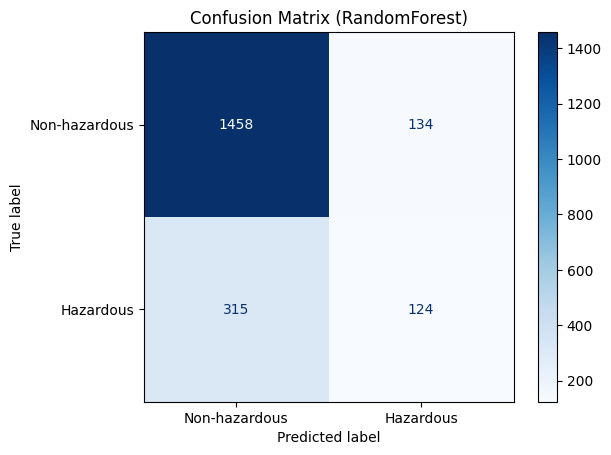

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# display for your best model (or inside the loop)
best_model_name = results_df.iloc[0]["model"]
print(f"\nConfusion Matrix for {best_model_name}:")

# Refit best pipeline if needed
best_model = candidates[best_model_name]
best_pipe = PipelineOptimization(best_model)
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)


# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Print absolute values
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

# Display confusion matrix for best model (RandomForest)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-hazardous", "Hazardous"])
disp.plot(cmap="Blues", values_format="d")
disp.ax_.set_title(f"Confusion Matrix ({best_model_name})")
plt.show()


Although this was the best model, recall of less than 30% is quite disappointing.
The next step is to look at grid search to tune parameters.

### Grid Search

We will use Grid Search to find better hyper-parameters for our models. We will also refine our metrics to weight more for True Positives (i.e. correctly predicting for Hazardous Asteroids)

In [11]:
# # Evaluate Model
# from sklearn.metrics import roc_auc_score
# from sklearn.metrics import average_precision_score
# y_pred = rf.predict(X_test)
# y_prob = rf.predict_proba(X_test)[:, 1]

# print("=== Classification report ===")
# print(classification_report(y_test, y_pred, digits=3))

# print("=== Confusion matrix ===")
# print(confusion_matrix(y_test, y_pred))

# roc_auc = roc_auc_score(y_test, y_prob)
# pr_auc = average_precision_score(y_test, y_prob)
# print(f"ROC AUC: {roc_auc:.3f} | PR AUC: {pr_auc:.3f}")

In [12]:
# ROC & PR curves
# fig, ax = plt.subplots(1, 2, figsize=(11,4))
# RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[0])
# ax[0].set_title("ROC Curve (Random Forest)")
# PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[1])
# ax[1].set_title("Precision-Recall Curve (Random Forest)")
# plt.tight_layout()
# plt.show()

In [13]:
# ### Feature Importance
# feat_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# plt.figure(figsize=(8,5))
# feat_importances.head(10).plot(kind="barh", color="teal")
# plt.title("Top Feature Importances (Random Forest)")
# plt.xlabel("Importance")
# plt.gca().invert_yaxis()
# plt.show()